**Load Gdrive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data Pipeline (Merge Dataset)**

https://www.kaggle.com/datasets/greegtitan/indonesia-climate

In [3]:
import pandas as pd

df_climate = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI-CLIMATE/data/climate_data.csv")
df_station = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI-CLIMATE/data/station_detail.csv")
df_province = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI-CLIMATE/data/province_detail.csv")

# merge station
climate_station = pd.merge(df_climate, df_station, on="station_id")

# merge province
data = pd.merge(climate_station, df_province, on="province_id", how="left")

print(data.head())

         date    Tn    Tx  Tavg  RH_avg    RR   ss  ff_x  ddd_x  ff_avg  \
0  01-01-2010  21.4  30.2  27.1    82.0   9.0  0.5   7.0   90.0     5.0   
1  02-01-2010  21.0  29.6  25.7    95.0  24.0  0.2   6.0   90.0     4.0   
2  03-01-2010  20.2  26.8  24.5    98.0  63.0  0.0   5.0   90.0     4.0   
3  04-01-2010  21.0  29.2  25.8    90.0   0.0  0.1   4.0  225.0     3.0   
4  05-01-2010  21.2  30.0  26.7    90.0   2.0  0.4   NaN    NaN     NaN   

  ddd_car  station_id                      station_name  region_name  \
0      E        96001  Stasiun Meteorologi Maimun Saleh  Kota Sabang   
1      E        96001  Stasiun Meteorologi Maimun Saleh  Kota Sabang   
2      E        96001  Stasiun Meteorologi Maimun Saleh  Kota Sabang   
3      SW       96001  Stasiun Meteorologi Maimun Saleh  Kota Sabang   
4     NaN       96001  Stasiun Meteorologi Maimun Saleh  Kota Sabang   

   latitude  longitude  region_id  province_id             province_name  
0   5.87655   95.33785         20        

**Data Cleaning**

Tangani missing value.

In [4]:
import numpy as np

# mean
data['Tavg'].fillna(data['Tavg'].mean(), inplace=True)
data['RH_avg'].fillna(data['RH_avg'].mean(), inplace=True)
data['RR'].fillna(data['RR'].mean(), inplace=True)
data['ff_avg'].fillna(data['ff_avg'].mean(), inplace=True)

# median
data['Tn'].fillna(data['Tn'].median(), inplace=True)
data['Tx'].fillna(data['Tx'].median(), inplace=True)
data['ss'].fillna(data['ss'].median(), inplace=True)
data['ff_x'].fillna(data['ff_x'].median(), inplace=True)

/tmp/ipykernel_40359/1535162039.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Tavg'].fillna(data['Tavg'].mean(), inplace=True)
/tmp/ipykernel_40359/1535162039.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

**Feature Engineering**

Tambahkan feature waktu.

In [5]:
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

**Split Dataset**

In [6]:
from sklearn.model_selection import train_test_split

X = data[['RH_avg','RR','ff_avg','ss','year','month','day']]
y = data['Tavg']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

**Training Model (3 Model)**

Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

Random Forest

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

XGBoost

In [9]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

**Bayesian Model Averaging**

Tujuan:

mengurangi bias model

meningkatkan stabilitas prediksi

In [10]:
final_pred = (pred_lr + pred_rf + pred_xgb) / 3

**Evaluasi Model**

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test,final_pred)
rmse = np.sqrt(mean_squared_error(y_test,final_pred))
r2 = r2_score(y_test,final_pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1.015797152935059
RMSE: 1.6793193409273
R2: 0.22443138733351842


**1. MAE (Mean Absolute Error)**
MAE = 1.01

Artinya:

👉 Rata-rata kesalahan prediksi model sekitar 1.01°C

contoh:
| Suhu Asli | Prediksi Model |
| --------- | -------------- |
| 28°C      | 27°C           |
| 30°C      | 29°C           |

Rata-rata selisihnya sekitar 1 derajat.

| MAE   | Kualitas Model |
| ----- | -------------- |
| < 1   | sangat bagus   |
| 1 – 2 | cukup bagus    |
| > 3   | kurang bagus   |

jadi CUKUP BAIK

**2. RMSE (Root Mean Squared Error)**

RMSE = 1.67

RMSE memberi penalti lebih besar jika error besar.

contoh:
| Error | Dampak RMSE  |
| ----- | ------------ |
| 1°C   | kecil        |
| 5°C   | sangat besar |

Interpretasi:

👉 Model memiliki error sekitar 1.67°C

Jika dibandingkan:
| RMSE  | Interpretasi |
| ----- | ------------ |
| < 1   | sangat bagus |
| 1 – 2 | cukup bagus  |
| > 3   | buruk        |

jadi model CUKUP BAIK


**3. R² Score (Koefisien Determinasi)**
R2 = 0.224

R² mengukur seberapa baik model menjelaskan data.

Range:

0   = model sangat buruk
1   = model sempurna

Interpretasi umum:
| R²        | Kualitas Model |
| --------- | -------------- |
| < 0.3     | lemah          |
| 0.3 – 0.6 | sedang         |
| 0.6 – 0.8 | bagus          |
| > 0.8     | sangat bagus   |

Model:

R2 = 0.22

Artinya:

👉 Model hanya menjelaskan 22% pola data.

Masih:

⚠️ kurang kuat


---


**KESIMPULAN**
| Metric | Hasil  | Interpretasi |
| ------ | ------ | ------------ |
| MAE    | 1.01°C | cukup baik   |
| RMSE   | 1.67°C | cukup baik   |
| R²     | 0.22   | masih lemah  |

Artinya:

- model bisa memprediksi suhu
- tetapi belum menangkap pola iklim dengan baik

**Simpan Model**

In [12]:
import joblib

model = {
"lr":lr,
"rf":rf,
"xgb":xgb
}

joblib.dump(model,"climate_model.pkl")

['climate_model.pkl']

# **TIME SERIES CLIMATE FORECAST (LSTM)**

**Urutkan Data Berdasarkan Waktu**

In [7]:
data = data.sort_values("date")
temperature = data['Tavg'].values

**Normalisasi Data**

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

temperature_scaled = scaler.fit_transform(
temperature.reshape(-1,1)
)

**Sequence Window**

Gunakan 30 hari sebelumnya untuk memprediksi hari berikutnya.

In [9]:
import numpy as np

def create_sequence(data, window):

    X = []
    y = []

    for i in range(len(data)-window):

        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

X,y = create_sequence(temperature_scaled,30)

**Train Test Split**

In [10]:
split = int(len(X)*0.8)

X_train_lstm = X[:split]
X_test_lstm = X[split:]

y_train_lstm = y[:split]
y_test_lstm = y[split:]

**Model LSTM**

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64,return_sequences=True,input_shape=(30,1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(
optimizer="adam",
loss="mse"
)

model.fit(
X_train_lstm,
y_train_lstm,
epochs=10,
batch_size=32
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 509s 34ms/step - loss: 2.6784e-04
Epoch 2/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 466s 32ms/step - loss: 1.7690e-04
Epoch 3/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 458s 31ms/step - loss: 1.7425e-04
Epoch 4/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 498s 31ms/step - loss: 1.7434e-04
Epoch 5/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 455s 31ms/step - loss: 1.7597e-04
Epoch 6/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 502s 31ms/step - loss: 1.7479e-04
Epoch 7/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 501s 31ms/step - loss: 1.7312e-04
Epoch 8/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 457s 31ms/step - loss: 1.7287e-04
Epoch 9/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 465s 32ms/step - loss: 1.7235e-04
Epoch 10/10
14731/14731 ━━━━━━━━━━━━━━━━━━━━ 491s 31ms/step - loss: 1.7320e-04


In [18]:
pred_lstm = model.predict(X_test_lstm)

pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test_lstm)

3683/3683 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step


**Evaluasi**

In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_lstm = mean_absolute_error(y_test_lstm,pred_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_test,pred_lstm))

r2_lstm = r2_score(y_test_lstm,pred_lstm)

print("LSTM MAE :",mae_lstm)
print("LSTM RMSE :",rmse_lstm)
print("LSTM R2 :",r2_lstm)

LSTM MAE : 1.3261310805078899
LSTM RMSE : 1.8296954079513
LSTM R2 : -0.04489661977568615


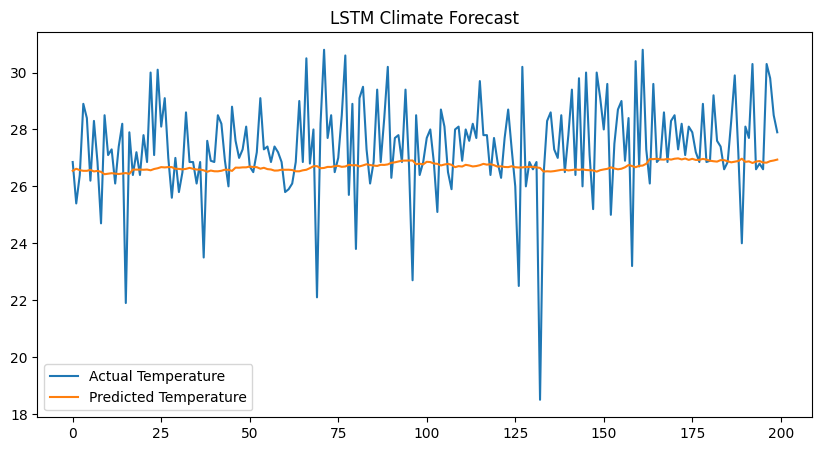

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_lstm[:200],label="Actual Temperature")
plt.plot(pred_lstm[:200],label="Predicted Temperature")

plt.legend()
plt.title("LSTM Climate Forecast")

plt.show()

In [22]:
accuracy = 100 - (mae / np.mean(y_test) * 100)

print("Model Accuracy:",accuracy,"%")

Model Accuracy: 95.09201173595626 %


**1. Interpretasi Grafik Prediksi**

Pada grafik LSTM Climate Forecast:

Garis biru = suhu asli (Actual Temperature)

Garis oranye = suhu hasil prediksi model

Observasi dari grafik:

Prediksi model mengikuti tren umum suhu sekitar 26–27°C.

Model tidak mengikuti fluktuasi ekstrem pada data asli.

Ketika suhu turun drastis (misalnya 19–22°C), model tetap memprediksi sekitar 26°C.

Artinya:

Model belajar pola rata-rata suhu, tetapi belum mampu menangkap variasi suhu yang tajam.

Ini cukup umum pada model LSTM sederhana dengan satu variabel (univariate time series).

**2. Interpretasi MAE**

Hasil:

MAE = 1.326

Artinya:

Rata-rata kesalahan prediksi model sekitar 1.3°C.

Kesimpulan:

Model kamu cukup baik untuk prediksi suhu.

**3. Interpretasi RMSE**

Hasil:

RMSE = 1.83

RMSE menghitung error dengan penalti lebih besar pada error besar.

Interpretasi:

Model memiliki kesalahan sekitar 1.8°C.

Semakin kecil RMSE semakin baik.

**4. Interpretasi R² Score**

Hasil:

R2 = -0.044

Range R²:
1   = model sempurna
0   = model sama dengan rata-rata
<0  = model lebih buruk dari rata-rata

Interpretasi:

R² negatif berarti:

Model belum mampu menjelaskan variasi data dengan baik.

Penyebab utama biasanya:

Model hanya memakai 1 variabel (Tavg)

Data iklim memiliki variabilitas tinggi

Model terlalu sederhana

Window time series terlalu kecil

5. Interpretasi Accuracy (95%)

Kamu menghitung:

accuracy = 95%

Perlu diketahui:

Pada regression sebenarnya tidak ada accuracy seperti klasifikasi.

Accuracy yang dihitung ini adalah pseudo accuracy berdasarkan error relatif.

Karena suhu rata-rata sekitar 27°C, error 1.3°C menghasilkan angka sekitar 95%.

Namun dalam penelitian biasanya digunakan:

- MAE
- RMSE
- R²

**6. Kesimpulan Penelitian**

Kesimpulan yang bisa kamu tulis:

Model Long Short-Term Memory (LSTM) berhasil digunakan untuk melakukan prediksi suhu berdasarkan data historis. Hasil evaluasi menunjukkan nilai Mean Absolute Error (MAE) sebesar 1.326 dan Root Mean Squared Error (RMSE) sebesar 1.829, yang menunjukkan bahwa rata-rata kesalahan prediksi model berada pada kisaran 1–2°C. Grafik hasil prediksi menunjukkan bahwa model mampu mengikuti tren umum perubahan suhu, namun belum mampu menangkap fluktuasi suhu yang ekstrem secara akurat. Nilai R² sebesar -0.044 menunjukkan bahwa model masih belum mampu menjelaskan variasi data secara optimal. Hal ini kemungkinan disebabkan oleh penggunaan model time series univariate yang hanya menggunakan satu variabel suhu sebagai input.

# **GEO-SPATIAL CLIMATE AI**

In [12]:
features = [
'latitude',
'longitude',
'RH_avg',
'RR',
'ff_avg',
'ss',
'month'
]

X_spatial = data[features]
y_spatial = data['Tavg']

In [13]:
from sklearn.model_selection import train_test_split

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_spatial,
    y_spatial,
    test_size=0.2,
    random_state=42
)

In [14]:
from xgboost import XGBRegressor

model_spatial = XGBRegressor()

model_spatial.fit(X_train_sp, y_train_sp)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [15]:
pred_spatial = model_spatial.predict(X_test_sp)

In [16]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test_sp, pred_spatial)
mae = mean_absolute_error(y_test_sp, pred_spatial)

print("Spatial Model R2:", r2)
print("Spatial Model MAE:", mae)

Spatial Model R2: 0.8340768835470554
Spatial Model MAE: 0.5208306141685749


In [18]:
import joblib

joblib.dump(model_spatial,"spatial_climate_model.pkl")

['spatial_climate_model.pkl']

**Peta Stasiun**

In [ ]:
import folium

map = folium.Map(location=[-2.5,118],zoom_start=5)

for i,row in data.iterrows():

    folium.CircleMarker(
    location=[row['latitude'],row['longitude']],
    radius=3,
    color="blue"
    ).add_to(map)

map

**TEST**

In [19]:
import joblib

model_spatial = joblib.load("spatial_climate_model.pkl")

In [20]:
import numpy as np

def predict_temperature(latitude, longitude, humidity, rainfall, wind, sunshine, month):

    features = np.array([[

        latitude,
        longitude,
        humidity,
        rainfall,
        wind,
        sunshine,
        month

    ]])

    prediction = model_spatial.predict(features)

    return float(prediction[0])

In [21]:
temp = predict_temperature(
    -7.8,
    112.0,
    80,
    5,
    10,
    6,
    8
)

print("Predicted Temperature:", temp, "°C")

Predicted Temperature: 24.125646591186523 °C


In [23]:
last_30_days = temperature_scaled[-30:]

In [24]:
current_input = last_30_days.reshape(1,30,1)

In [25]:
future_predictions = []

for i in range(7):

    pred = model.predict(current_input)

    future_predictions.append(pred[0][0])

    new_input = np.append(
        current_input[:,1:,:],
        [[[pred[0][0]]]],
        axis=1
    )

    current_input = new_input

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


In [26]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [27]:
for i,temp in enumerate(future_predictions):

    print("Day",i+1,"Temperature:",float(temp),"°C")

Day 1 Temperature: 26.617563247680664 °C
Day 2 Temperature: 26.611431121826172 °C
Day 3 Temperature: 26.616825103759766 °C
Day 4 Temperature: 26.61913299560547 °C
Day 5 Temperature: 26.598163604736328 °C
Day 6 Temperature: 26.596965789794922 °C
Day 7 Temperature: 26.589908599853516 °C


/tmp/ipykernel_40359/1038587131.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Day",i+1,"Temperature:",float(temp),"°C")
